(mmm_placebo_check)=
# Placebo Channels: How Much Credit Does the Model Give to Nothing?

A media mix model is fitted against the same outcome it is later asked to explain. Whatever the intercept, the seasonality and the controls leave unexplained has to go somewhere, and every channel in the model is a candidate. So a channel's contribution is never purely its effect: part of it is the share of leftover variation that any plausible-looking spend series would have collected.

A **placebo channel** measures that part directly. Take a real spend series, destroy its alignment with the outcome, put it back in the model as an ordinary channel, and refit. It cannot have caused anything. Whatever contribution the model still assigns to it is the floor — the amount of credit this model, on this data, hands out for nothing. Contributions worth acting on have to clear that floor.

This is the *negative control* idea from epidemiology ([Lipsitch, Tchetgen Tchetgen & Cohen, 2010](https://pubmed.ncbi.nlm.nih.gov/20335814/)) applied to attribution: an exposure known to have no effect, carried through the identical analysis, tells you what the analysis produces in the absence of an effect.

The construction itself is a few lines of NumPy, so this notebook is the whole recipe rather than an API to import.

## Prepare Notebook

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pymc_extras.prior import Prior

from pymc_marketing.mmm import GeometricAdstock, LogisticSaturation
from pymc_marketing.mmm.mmm import MMM
from pymc_marketing.paths import data_dir
from pymc_marketing.special_priors import LaplacePrior, LogNormalPrior

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100

In [2]:
seed: int = sum(map(ord, "mmm_placebo"))
rng: np.random.Generator = np.random.default_rng(seed=seed)

## Data

We reuse the simulated data set and the model specification of the {ref}`mmm_multidimensional_example`: one product, two geos, two channels, two event controls. That notebook describes the data as noisy and low-signal, and asks whether the model can parse the signal out of it. The placebo channel turns that question into a number.

In [3]:
data_df = pd.read_csv(
    data_dir / "mmm_multidimensional_example.csv", parse_dates=["date"]
)

data_df.head()

,date,geo,x1,x2,event_1,event_2,y
0,2022-06-06,geo_a,5527.640078,0.000000,0,0,2647.596355
1,2022-06-06,geo_b,8849.257500,8063.918386,0,0,682.406280
2,2022-06-13,geo_a,6692.655692,0.000000,0,0,5020.823907
3,2022-06-13,geo_b,9073.817994,9354.014585,0,0,3753.104897
4,2022-06-20,geo_a,7124.016733,0.000000,0,0,6184.322132


## Building the placebo channel

We copy channel `x1` and break its alignment with the outcome by rolling it forward by a random offset, within each geo. Two properties matter:

- **Circular shift keeps the shape of the series.** The flighting pattern, the autocorrelation and the seasonality of spend all survive; only the timing relative to sales is destroyed. That makes it a *hard* placebo: it looks exactly like a media series in every respect the model can exploit, except the one that matters.
- **A random permutation is the easier variant.** It preserves only the marginal distribution of spend, so it is visibly not a media series. Use it as a second, weaker check, or when the shift happens to leave the placebo correlated with the original.

We keep the shift within a geo so the placebo stays a plausible series for that market.

In [4]:
def add_placebo_channel(
    df: pd.DataFrame,
    channel: str,
    group_column: str,
    rng: np.random.Generator,
    name: str | None = None,
) -> tuple[pd.DataFrame, str]:
    """Copy a spend column and destroy its alignment with the outcome."""
    name = name or f"{channel}_placebo"
    shifted = []
    for _, group in df.groupby(group_column, sort=False):
        values = group[channel].to_numpy()
        # an offset of 0 would hand back the real channel
        offset = int(rng.integers(1, len(values)))
        shifted.append(pd.Series(np.roll(values, offset), index=group.index))
    out = df.copy()
    out[name] = pd.concat(shifted).sort_index()
    return out, name


data_df, placebo = add_placebo_channel(data_df, "x1", group_column="geo", rng=rng)
channels = ["x1", "x2", placebo]

print(f"placebo column: {placebo}")
print(f"correlation with the real channel: {data_df['x1'].corr(data_df[placebo]):.3f}")

placebo column: x1_placebo
correlation with the real channel: 0.082


The correlation with the real channel is small, which is what we want: the placebo carries the *look* of a media series without carrying its timing. Check this number every time — a shift that happens to land near the period of a strongly seasonal series can leave the placebo highly correlated with the original, and then the two channels are competing for the same credit for a different reason.

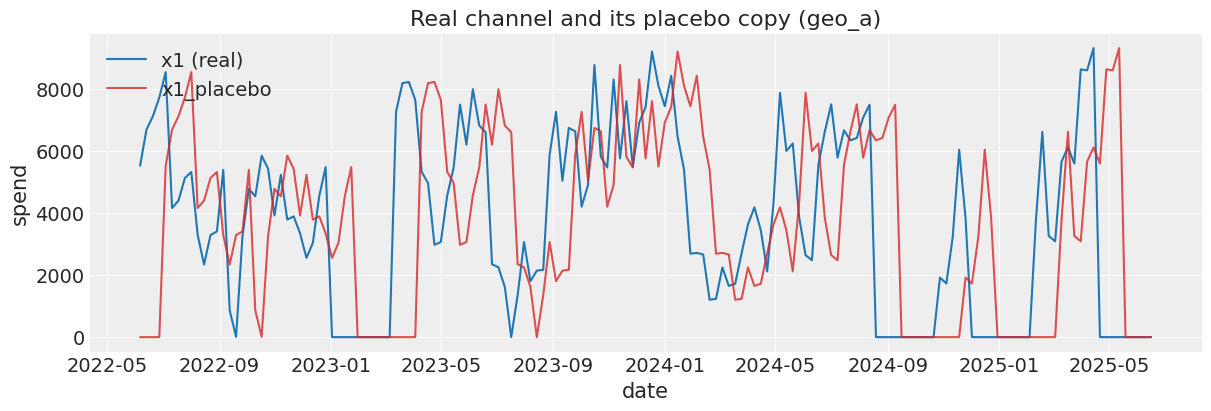

In [5]:
geo = "geo_a"
subset = data_df[data_df["geo"] == geo]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(subset["date"], subset["x1"], label="x1 (real)", color="#1f77b4")
ax.plot(subset["date"], subset[placebo], label=f"{placebo}", color="#d62728", alpha=0.8)
ax.set(
    title=f"Real channel and its placebo copy ({geo})", xlabel="date", ylabel="spend"
)
ax.legend();

## Model

The specification is the one from the {ref}`mmm_multidimensional_example`, with a single change: the placebo enters `channel_columns` as an ordinary channel. It gets the same adstock, the same saturation and the same priors as the real channels. Nothing marks it out to the model — that is the point.

In [6]:
def build_mmm(channel_columns: list[str]) -> MMM:
    beta_prior = LogNormalPrior(
        mean=Prior("Gamma", mu=0.25, sigma=0.10, dims="channel"),
        std=Prior("Exponential", scale=0.10, dims="channel"),
        dims=("channel", "geo"),
        centered=False,
    )
    saturation = LogisticSaturation(
        priors={
            "beta": beta_prior,
            "lam": Prior("Gamma", mu=0.5, sigma=0.25, dims="channel"),
        }
    )
    adstock = GeometricAdstock(
        priors={"alpha": Prior("Beta", alpha=2, beta=5, dims=("geo", "channel"))},
        l_max=8,
    )
    model_config = {
        "intercept": Prior("Gamma", mu=0.5, sigma=0.25, dims="geo"),
        "gamma_control": Prior("Normal", mu=0, sigma=0.5, dims="control"),
        "gamma_fourier": LaplacePrior(
            mu=0,
            b=Prior("HalfNormal", sigma=0.2),
            dims=("geo", "fourier_mode"),
            centered=False,
        ),
        "likelihood": Prior(
            "TruncatedNormal",
            lower=0,
            sigma=Prior("HalfNormal", sigma=1.5),
            dims=("date", "geo"),
        ),
    }
    return MMM(
        date_column="date",
        target_column="y",
        channel_columns=channel_columns,
        control_columns=["event_1", "event_2"],
        dims=("geo",),
        scaling={
            "channel": {"method": "max", "dims": ()},
            "target": {"method": "max", "dims": ()},
        },
        adstock=adstock,
        saturation=saturation,
        yearly_seasonality=2,
        model_config=model_config,
    )


def fit_mmm(X: pd.DataFrame, y: pd.Series, rng: np.random.Generator) -> MMM:
    mmm = build_mmm(channels)
    mmm.build_model(X=X, y=y)
    # contributions on the original scale are comparable across geos
    mmm.add_original_scale_contribution_variable(var=["channel_contribution"])
    mmm.fit(
        X=X,
        y=y,
        chains=4,
        draws=500,
        tune=500,
        target_accept=0.95,
        nuts_sampler="nutpie",
        random_seed=rng,
        progressbar=False,
    )
    return mmm

In [7]:
X = data_df.drop(columns=["y"])
y = data_df["y"]

mmm = fit_mmm(X, y, rng)

print(f"divergences: {int(mmm.idata.sample_stats.diverging.sum())}")

divergences: 0


## Reading the result

For each channel we take its total absolute contribution across dates and geos, express it as a share of the total across channels, and keep the whole posterior rather than a point estimate. Two quantities come out of it:

- the **share** the model assigns to the placebo — the floor;
- for every real channel, **P(> placebo)**: the fraction of posterior draws in which that channel's share exceeds the placebo's. This is the number to act on. It turns "this channel looks important" into "this channel beats a series that cannot have caused anything, in this fraction of the posterior".

In [8]:
def placebo_table(mmm: MMM, placebo_name: str, hdi_prob: float = 0.94) -> pd.DataFrame:
    contribution = mmm.idata.posterior["channel_contribution_original_scale"]
    extra_dims = [d for d in contribution.dims if d not in ("chain", "draw", "channel")]
    share = np.abs(contribution).sum(dim=extra_dims)
    share = share / share.sum(dim="channel")
    placebo_share = share.sel(channel=placebo_name)

    rows = []
    for channel in share.channel.values:
        draws = share.sel(channel=channel)
        low, high = np.asarray(az.hdi(draws.values.ravel(), prob=hdi_prob)).ravel()
        rows.append(
            {
                "channel": channel,
                "share": float(draws.mean()),
                "hdi_low": float(low),
                "hdi_high": float(high),
                "P(> placebo)": np.nan
                if channel == placebo_name
                else float((draws > placebo_share).mean()),
            }
        )
    return pd.DataFrame(rows).sort_values("share", ascending=False).set_index("channel")


summary = placebo_table(mmm, placebo)
summary.round(3)

,share,hdi_low,hdi_high,P(> placebo)
channel,,,,
x1,0.451,0.145,0.766,0.784
x2,0.309,0.038,0.572,0.628
x1_placebo,0.240,0.013,0.495,NaN


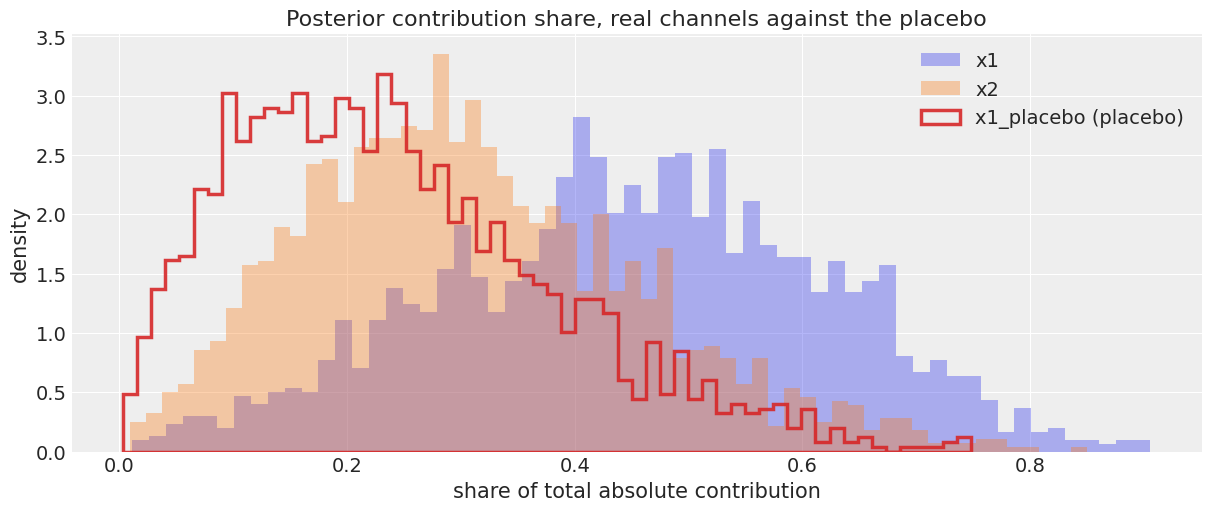

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))

contribution = mmm.idata.posterior["channel_contribution_original_scale"]
extra_dims = [d for d in contribution.dims if d not in ("chain", "draw", "channel")]
share = np.abs(contribution).sum(dim=extra_dims)
share = share / share.sum(dim="channel")

for channel in summary.index:
    is_placebo = channel == placebo
    ax.hist(
        share.sel(channel=channel).values.ravel(),
        bins=60,
        density=True,
        histtype="stepfilled",
        alpha=0.9 if is_placebo else 0.35,
        fill=not is_placebo,
        linewidth=2.5 if is_placebo else 1.5,
        edgecolor="#d62728" if is_placebo else None,
        color="#d62728" if is_placebo else None,
        label=f"{channel} (placebo)" if is_placebo else channel,
    )

ax.set(
    title="Posterior contribution share, real channels against the placebo",
    xlabel="share of total absolute contribution",
    ylabel="density",
)
ax.legend();

The placebo is not a thin spike at zero. It collects a substantial share of the credit, and the real channels' posteriors overlap it heavily: neither of them clears the floor with much confidence. Given how the multidimensional example describes this data — deliberately noisy, low signal — that is the honest read, and it is the read the contribution plot alone does not give you. A channel contribution chart without a placebo shows two bars of respectable size and says nothing about how large a bar this model produces for a series with no relationship to sales at all.

Note also what the placebo's floor is made of. `saturation_beta` is strictly positive here, so *every* channel contributes something by construction; a placebo cannot come back at exactly zero in this parameterisation. That is not a flaw in the check — it is the quantity being measured. It is also why **P(> placebo)** rather than the raw share is the number to read.

## Can this check fail?

A diagnostic that always reassures is not a diagnostic. So we run it once more on data where we know the answer: the same channels, the same model, but the outcome scrambled within each geo. The spend series keep their structure, the target keeps its marginal distribution, and every causal link between them is gone. Nothing can be found, so nothing should clear the placebo.

In [10]:
y_scrambled = (
    y.groupby(data_df["geo"], sort=False)
    .transform(lambda s: rng.permutation(s.to_numpy()))
    .rename("y")
)

mmm_null = fit_mmm(X, y_scrambled, rng)

print(f"divergences: {int(mmm_null.idata.sample_stats.diverging.sum())}")
placebo_table(mmm_null, placebo).round(3)

divergences: 0


,share,hdi_low,hdi_high,P(> placebo)
channel,,,,
x1_placebo,0.363,0.047,0.676,NaN
x1,0.354,0.049,0.665,0.491
x2,0.283,0.025,0.565,0.385


On the scrambled target the placebo comes out on top and the real channels sit at **P(> placebo) near or below 0.5** — a coin flip, which is exactly what "no evidence of an effect" should look like on this scale. The check discriminates: it is not simply reporting a number that always looks acceptable.

That also calibrates the earlier table. The real-target run is somewhere between this null and a clear result, not at either end.

## What this does and does not tell you

**It tells you** how much contribution your model hands to a series that cannot have caused anything — under your priors, your controls, your seasonality and your data. That floor is model-specific and data-specific, which is why it has to be measured rather than assumed.

**It does not tell you** that a channel clearing the placebo is causal. A placebo landing low rules out one failure mode — indiscriminate attribution of leftover variation — and leaves the others untouched: confounding, reverse causality, and selection into spend all survive a placebo check comfortably. Necessary, not sufficient.

Practical notes:

- Build the placebo from a **real** spend series rather than random noise. A noise channel is trivially rejected and tells you nothing about how the model treats series that look like media.
- Always check the correlation between the placebo and its source. If the shift leaves them correlated, use the permutation variant, or a different offset.
- Several placebos, from different source channels, give a better sense of the floor than one.
- Rerun the check whenever the model specification changes. The floor moves with the priors and the controls, not just with the data.

In [11]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing,pytensor,nutpie

Last updated: Tue, 11 Aug 2026

Python implementation: CPython
Python version       : 3.14.6
IPython version      : 9.16.1

pymc_marketing: 1.0.0
pytensor      : 3.0.7
nutpie        : 0.16.11

arviz         : 1.2.0
matplotlib    : 3.10.9
numpy         : 2.4.6
pandas        : 2.3.3
pymc_extras   : 0.12.2.dev1+gee8cc37df
pymc_marketing: 1.0.0

Watermark: 2.6.0

